In [1]:
try:
    import spherinator
except ImportError:
    %pip -q install git+https://github.com/HITS-AIN/Spherinator
    import spherinator
print(spherinator.__version__)

/home/doserbd/git/Tutorial-Spherinator/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


0.5.1


In [2]:
datamodule = spherinator.data.DataModule(
    path="HITS-AIN/IllustrisTNG_SKIRT_SDSS",
    columns=["image"],
    return_dict=False,
    batch_size=25,
    shuffle=True,
    num_workers=4,
)

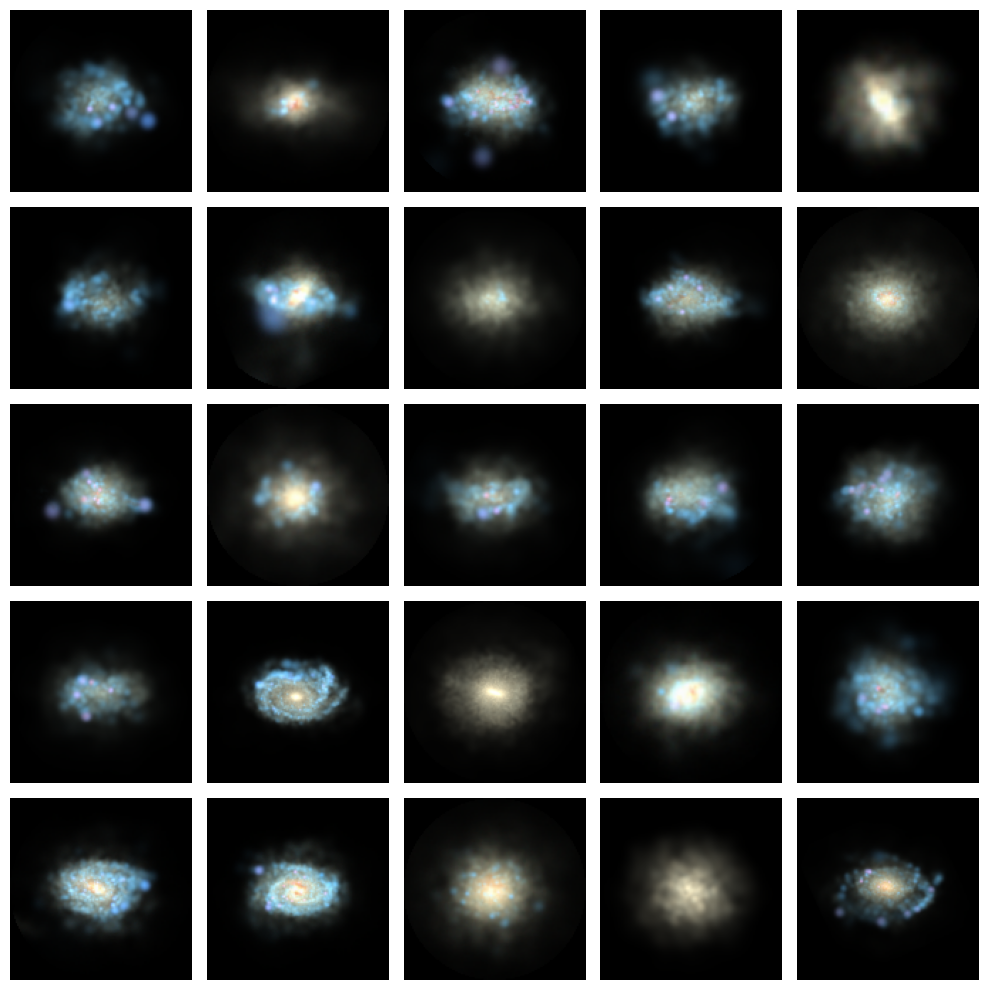

In [3]:
import matplotlib.pyplot as plt

# Set up the data module and fetch one batch of images
datamodule.setup("fit")
images = next(iter(datamodule.train_dataloader()))

fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for ax, image in zip(axes.flat, images):
    ax.imshow(image.permute(1, 2, 0))  # [3, 128, 128] -> [128, 128, 3]
    ax.axis("off")
fig.tight_layout()
plt.show()


In [ ]:
import spherinator
import torch

model = spherinator.models.VariationalAutoencoder(
    encoder=spherinator.models.HuggingFaceResNetEncoder(
        model_name="microsoft/resnet-18", output_dim=256
    ),
    decoder=spherinator.models.Sequential(
        modules=[
            torch.nn.Linear(in_features=3, out_features=256),
            spherinator.models.UpsamplingDecoder2D(
                input_dim=256, output_dim=[3, 128, 128], base_channels=512, seed_size=4
            ),
        ]
    ),
    reconstruction_loss=torch.nn.L1Loss(),
    z_dim=3,
    beta=1e-6,
    encoder_out_dim=256,
    max_scale=1e4,
)

Loading weights: 100%|██████████| 120/120 [00:00<00:00, 9830.78it/s]
[transformers] ResNetModel LOAD REPORT from: microsoft/resnet-18
Key                 | Status     |  | 
--------------------+------------+--+-
classifier.1.weight | UNEXPECTED |  | 
classifier.1.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
from lightning.pytorch import Trainer

trainer = Trainer(
    max_epochs=10,
    accelerator="auto",
    precision="16-mixed",
)
trainer.fit(model, datamodule=datamodule)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/doserbd/git/Tutorial-Spherinator/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModel

RuntimeError: CUDNN_BACKEND_TENSOR_DESCRIPTOR cudnnFinalize failedptrDesc->finalize() cudnn_status: CUDNN_STATUS_SUBLIBRARY_VERSION_MISMATCH